In [1]:
# Cell 1: generate synthetic dataset (toy example)
import pandas as pd
import numpy as np

np.random.seed(42)

# sample game titles (example list; you can replace with real titles)
game_titles = [
    "Brain Training", "Mario Kart DS", "Animal Crossing: Wild World",
    "Professor Layton", "Cooking Mama", "Nintendogs", "Sonic Rush"
]

n = 200  # number of rows

data = {
    "game_title": np.random.choice(game_titles, n),
    "release_year": np.random.choice(range(2005, 2013), n),
    # units sold in thousands perhaps
    "units_sold_manchester": np.random.poisson(lam=50, size=n),
    "price_gbp": np.random.normal(loc=25, scale=5, size=n).round(2),
    # assume cost per unit
    "cost_gbp": np.random.normal(loc=12, scale=3, size=n).round(2),
    # demographic
    "demographic_age_group": np.random.choice(
        ["10-12", "13-17", "18-24", "25-34", "35-44", "45+"], n),
    "demographic_gender": np.random.choice(
        ["Male", "Female", "Other", "Unknown"], n),
    "city_subregion": np.random.choice(
        ["Manchester City Centre", "Salford", "Oldham", "Stockport",
         "Bolton", "Trafford"], n),
}

df = pd.DataFrame(data)

# compute revenue and profit
df["revenue_gbp"] = (df["units_sold_manchester"] * df["price_gbp"]).round(2)
df["profit_gbp"] = (
    df["units_sold_manchester"] * (df["price_gbp"] - df["cost_gbp"])
).round(2)
# avoid divide by zero
df["profit_margin"] = np.where(
    df["revenue_gbp"] > 0,
    (df["profit_gbp"] / df["revenue_gbp"]).round(4),
    0,
)

# add a short text field for NLP example
comments = [
    "Great game, kids loved it!",
    "Too difficult for younger players.",
    "Good value for money.",
    "Could improve graphics.",
    "Excellent teaching tool.",
    "Not much replay value.",
    "Loved the multiplayer mode."
]
df["customer_comments"] = np.random.choice(comments, n)

# save to CSV for later use
csv_path = "ds_games_manchester_sales.csv"
df.to_csv(csv_path, index=False)
print(f"Generated synthetic dataset to {csv_path}")
df.head()

Generated synthetic dataset to ds_games_manchester_sales.csv


,game_title,release_year,units_sold_manchester,price_gbp,cost_gbp,demographic_age_group,demographic_gender,city_subregion,revenue_gbp,profit_gbp,profit_margin,customer_comments
0,Sonic Rush,2010,42,34.23,14.85,25-34,Female,Salford,1437.66,813.96,0.5662,Loved the multiplayer mode.
1,Professor Layton,2005,50,26.33,13.62,35-44,Male,Stockport,1316.50,635.50,0.4827,Too difficult for younger players.
2,Cooking Mama,2009,47,23.93,16.04,25-34,Unknown,Trafford,1124.71,370.83,0.3297,"Great game, kids loved it!"
3,Sonic Rush,2010,55,25.69,12.38,35-44,Unknown,Stockport,1412.95,732.05,0.5181,Too difficult for younger players.
4,Animal Crossing: Wild World,2008,51,28.82,9.72,18-24,Male,Trafford,1469.82,974.10,0.6627,Good value for money.


In [2]:
# Cell 2: read the dataset
import pandas as pd

# if using the synthetic CSV generated above
df = pd.read_csv("ds_games_manchester_sales.csv")

# if you have a different CSV, change the path accordingly
# df = pd.read_csv("your_real_dataset.csv")

df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   game_title             200 non-null    object 
 1   release_year           200 non-null    int64  
 2   units_sold_manchester  200 non-null    int64  
 3   price_gbp              200 non-null    float64
 4   cost_gbp               200 non-null    float64
 5   demographic_age_group  200 non-null    object 
 6   demographic_gender     200 non-null    object 
 7   city_subregion         200 non-null    object 
 8   revenue_gbp            200 non-null    float64
 9   profit_gbp             200 non-null    float64
 10  profit_margin          200 non-null    float64
 11  customer_comments      200 non-null    object 
dtypes: float64(5), int64(2), object(5)
memory usage: 18.9+ KB


,game_title,release_year,units_sold_manchester,price_gbp,cost_gbp,demographic_age_group,demographic_gender,city_subregion,revenue_gbp,profit_gbp,profit_margin,customer_comments
count,200,200.000000,200.000000,200.000000,200.000000,200,200,200,200.000000,200.00000,200.000000,200
unique,7,NaN,NaN,NaN,NaN,6,4,6,NaN,NaN,NaN,7
top,Sonic Rush,NaN,NaN,NaN,NaN,45+,Male,Salford,NaN,NaN,NaN,Not much replay value.
freq,37,NaN,NaN,NaN,NaN,38,55,40,NaN,NaN,NaN,34
mean,NaN,2008.375000,49.615000,25.421200,12.140250,NaN,NaN,NaN,1260.294600,656.37485,0.493644,NaN
std,NaN,2.448336,6.552208,5.516877,2.866966,NaN,NaN,NaN,313.861039,307.88155,0.210579,NaN
min,NaN,2005.000000,31.000000,7.160000,3.860000,NaN,NaN,NaN,343.680000,-394.56000,-1.148000,NaN
25%,NaN,2006.000000,45.750000,21.860000,10.557500,NaN,NaN,NaN,1061.535000,452.22750,0.413425,NaN
50%,NaN,2008.000000,50.000000,25.735000,12.155000,NaN,NaN,NaN,1250.075000,654.28000,0.520450,NaN
75%,NaN,2010.250000,54.000000,29.032500,14.055000,NaN,NaN,NaN,1469.370000,854.37750,0.611700,NaN


game_title               0
release_year             0
units_sold_manchester    0
price_gbp                0
cost_gbp                 0
demographic_age_group    0
demographic_gender       0
city_subregion           0
revenue_gbp              0
profit_gbp               0
profit_margin            0
customer_comments        0
dtype: int64
demographic_age_group
45+      38
25-34    37
10-12    33
18-24    32
13-17    32
35-44    28
Name: count, dtype: int64
demographic_gender
Male       55
Unknown    51
Female     48
Other      46
Name: count, dtype: int64


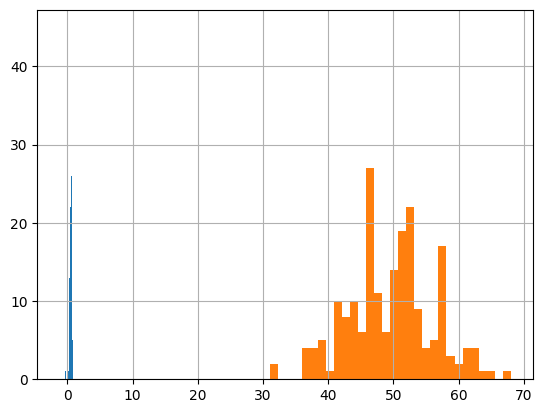

In [3]:
# Cell 3: quick checks
print(df.isna().sum())

# distribution of profit_margin
df["profit_margin"].hist(bins=30)

# units sold distribution
df["units_sold_manchester"].hist(bins=30)

# demographics counts
print(df["demographic_age_group"].value_counts())
print(df["demographic_gender"].value_counts())

In [5]:
# Cell 4 + Cell 5: full correct code (prep + model + evaluation)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------
# 1) target
# -----------------------
y = df["profit_margin"]          # or: df["profit_gbp"]

# -----------------------
# 2) features
# -----------------------
numeric_features = ["units_sold_manchester", "price_gbp"]
categorical_features = ["demographic_age_group", "demographic_gender"]

X = df[numeric_features + categorical_features]

# -----------------------
# 3) preprocessing
# -----------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
         categorical_features),
    ],
    remainder="drop"
)

# -----------------------
# 4) train/test split
# -----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------
# 5) pipeline + model
# -----------------------
model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("regressor", LinearRegression())
])

# -----------------------
# 6) fit
# -----------------------
model.fit(X_train, y_train)

# -----------------------
# 7) predict + evaluate
# -----------------------
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R^2:  {r2:.4f}")

RMSE: 0.1416
R^2:  0.4783


In [7]:
print(model)
print(model.named_steps)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['units_sold_manchester',
                                                   'price_gbp']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['demographic_age_group',
                                                   'demographic_gender'])])),
                ('regressor', LinearRegression())])
{'preprocess': ColumnTransformer(transformers=[('num', 'passthrough',
                                 ['units_sold_manchester', 'price_gbp']),
                                ('cat',
                                 OneHotEncoder(drop='fi

In [8]:
# Cell 7: simple rule-based sentiment
import numpy as np

def simple_sentiment(text):
    text_lower = text.lower()
    if any(word in text_lower for word in ["great", "excellent", "loved", "good"]):
        return "positive"
    if any(word in text_lower for word in ["too difficult", "not much", "could improve"]):
        return "negative"
    return "neutral"

df["sentiment"] = df["customer_comments"].apply(simple_sentiment)
df["sentiment"].value_counts()

sentiment
positive    104
negative     96
Name: count, dtype: int64

In [9]:
# Cell 8: TF-IDF transformation + clustering or basic classification
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

texts = df["customer_comments"].values
tfidf = TfidfVectorizer(stop_words="english", ngram_range=(1,2))
X_text = tfidf.fit_transform(texts)

# Cluster comments into 2-3 groups
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_text)
df["text_cluster"] = clusters

# see top terms per cluster
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
terms = tfidf.get_feature_names_out()
for i in range(3):
    top_terms = [terms[ind] for ind in order_centroids[i, :5]]
    print(f"Cluster {i} top terms: {top_terms}")

Cluster 0 top terms: ['graphics', 'improve', 'improve graphics', 'younger players', 'players']
Cluster 1 top terms: ['value', 'replay value', 'replay', 'good', 'value money']
Cluster 2 top terms: ['loved', 'multiplayer mode', 'loved multiplayer', 'mode', 'multiplayer']
